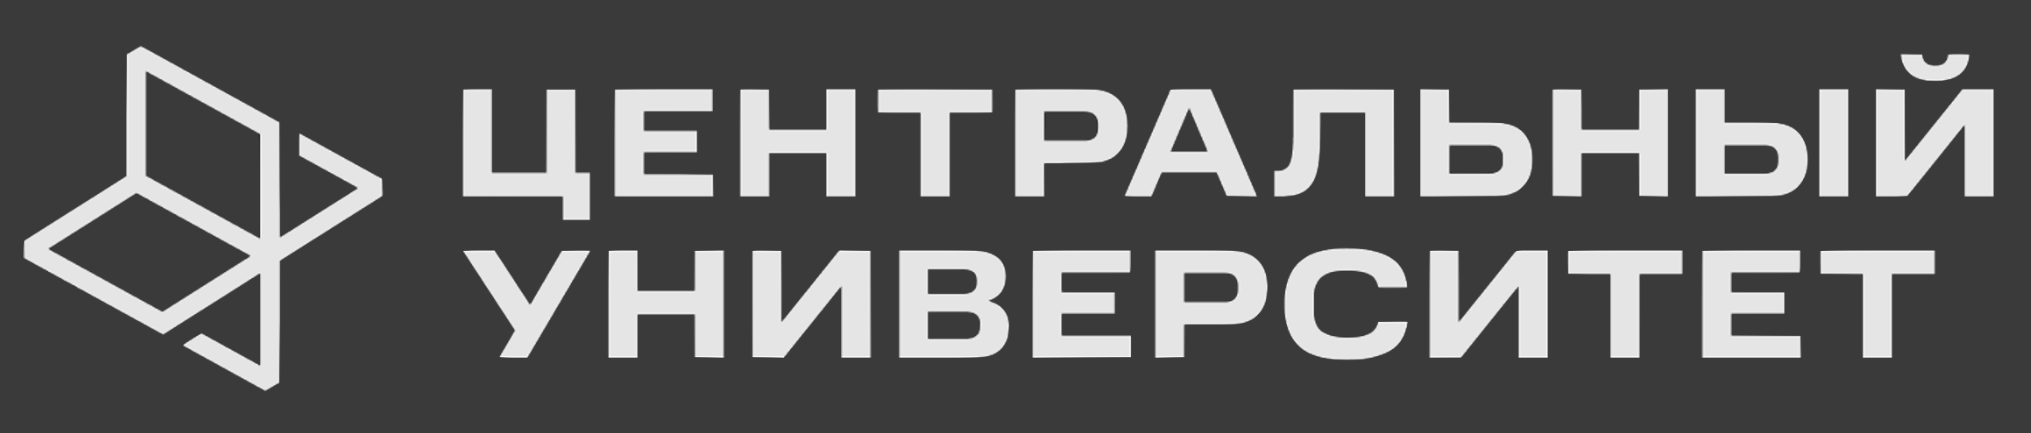

<hr style="border:2px solid gray">

## Домашнее задание 2. Задача детектирования и классификации объектов.


# О формате сдачи

🔷 **<font color='plum'>При решении ноутбука используйте данный шаблон</font>**

    ✅ Можно добавлять новые ячейки любых типов
    ❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий


🔷 **<font color='plum'>При оценивании задач учитывается код</font>**

    ✅ Задания, в которых необходим код, обычно помечаются фразами "Your code here"/"Ваш код" и аналогичными
    ❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
    ❌ Наличие работоспособного кода в ноутбуке, если на сказано иного, обязательно

🔷 **<font color='plum'>При оценивании задач учитываются выводы</font>**

    ✅ Задания, в которых необходимы выводы, обычно помечаются фразами Вывод"/"Ответ на вопрос"/"Ваш текст" и аналогичными
    ✅ Обычно выводы подразумевают под собой текстовый ответ (можно писать markdown, latex).
    ✅ Сопутствующие изображения, графики, таблички - приветствуются!
    ❌ При отсутствии выводов задание не засчитается на полный балл

----
## <font color='OrangeRed'>**Внимание! Алярм! Ахтунг!**</font>

* Данный ноутбук желательно выполнять на внутреней платформе <font color='DarkSeaGreen'>**jupyter.culab**</font> ЦУ.

* Работоспособность данного ноутбука проверена именно на <font color='DarkSeaGreen'>**jupyter.culab**</font>, работоспособность "из-под коробки" на других платформах мы не гарантируем.

* Вы можете делать задание у себя локально/Google Colab/Kaggle и пр. при желании, однако работать с доп файлами и настраивать окружение придется самостоятельно.

* Подробнее о использовании внутренней платформы читайте в описании курса

---
## Формулировка задания

- <font color='DarkOrange'> **[3 баллa]** </font> Воспользоваться материалами семинара разработать модель на основе `ResNet18` архитектуры.
- <font color='DarkOrange'> **[3 балла]** </font>Натренировать модель на основе `ResNet18` архитектуры.
- <font color='DarkOrange'> **[1 балл]** </font>Сравнить скорость работы моделей, основаных на `VGG16` и `ResNet18`.
- <font color='DarkOrange'> **[1 балл]** </font>Сравнить между собой метрики `MAP` для натренированных моделей, основаных на `VGG16` и `ResNet18`.
- <font color='DarkOrange'> **[2 балла]** </font>Визуализация результатов и описание проведенных экспериментов, выводы.

### <font color='MediumSeaGreen'> **Бонусы** </font>
- Применяются для каждой части отдельно
- <font color='MediumSeaGreen'> **[0.5 балла]** </font> Бонус можно получить за визуализацию результатов  в `wandb` - приложите ссылку на отчет о обучении на wandb, подкрепляя это графиками и выводами
- <font color='MediumSeaGreen'> **[до 5 баллов]** </font>Бонус можно получить за попытки реализовать свою архитектуру: например на семинаре мы цепляли пару сверточных слоев, чтобы получить предсказания для поправок `prior_boxes` и `scores` классов, попробуйте реализовать что-то посложнее.
---

<font color='OrangeRed'>**Внимание!**</font> мы тренируем модели на три класса `car, license_plate, background`, поэтому внесите исправления в файле `voc_dataset.py`

<font color='OrangeRed'>**Внимание!**</font> Сохраняйте <font color='OrangeRed'>**все итоговые**</font>, и, лучше, промежуточные результаты обучения и веса и архитуктуры моделей! Данные модели пригодятся вам в дальнейшем при построении целостного проекта!


<font color='OrangeRed'>**Внимание!**</font> SSD на VGG обучается порядка 1 минуты на эпоху, для хорошего результата нужно не менее 20-30 эпох. SSD на ResNet обучается до 0.4 минут на эпоху, для хорошего результата нужно не менее 20-30 эпох

<font color='OrangeRed'>**Внимание!**</font> Вам выдается набор данных с изображениями в разрешении $640{\times}360$ и $1280{\times}720$. Для тренировки модели на `VGG16` используйте $640x360$. Для тренировки модели на `ResNet18` нужно использовать $1280{\times}720$, поскольку регистрационные знаки имеют маленький размер более высокое разрешение позволит из **лучше** детектировать.

<font color='OrangeRed'>**Внимание!**</font> SSD на VGG потребляет большое количество видеопамяти, рекомендуемый batch_size = 3. SSD на ResNet требует существенно меньше память, рекомендуемый batch_size = 6. В случае, если ноутбук падает при таком batch_size, уменьшите его


## Архитектура модели на базе `RESNET18`

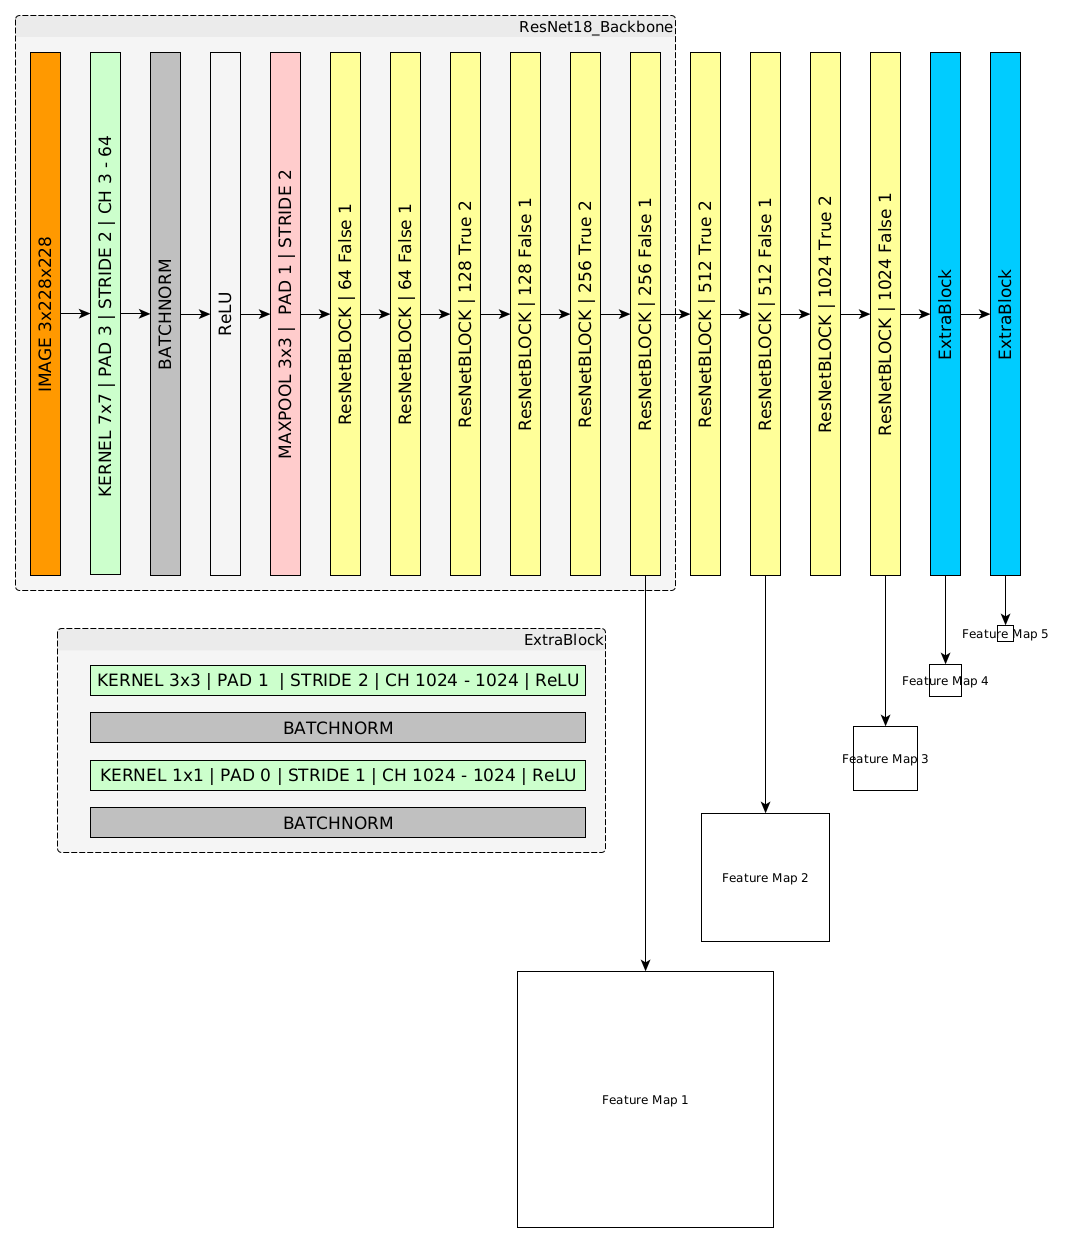

In [6]:
import os
import sys
import time
from pathlib import Path
import warnings


# Убираем все ворнинги
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")

WEEK2 = Path.cwd().resolve()
sys.path.insert(0, str(WEEK2 / "utils"))

import torch
from torch.optim import Adam, AdamW
from tqdm.auto import tqdm

from voc_dataloader import get_train_dataloader, get_test_dataloader
from voc_dataset import strong_transform, strong_transform_resnet
from multibox_loss import MultiBoxLoss
from compute_map import compute_map, log_eval_map
from prior_boxes import prior_boxes, detect_objects
from ssd_resnet18 import SSDResNet18, ssd_resnet18_cfg
from ssd_resnet18 import build_priors as build_priors_resnet18
from ssd_vgg16 import SSDVGG16, ssd_vgg_cfg
from ssd_vgg16 import build_priors as build_priors

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

### Week1 

-  <font color='DarkOrange'> **[5 баллов]** </font> Воспользоваться материалами семинара и натренировать модель на основе `VGG16` на предлагаемом наборе.
- Самостоятельно разобраться с метрикой [`MAP`](https://torchmetrics.readthedocs.io/en/v0.8.2/detection/mean_average_precision.html)
- <font color='DarkOrange'> **[3 балла]** </font> Добавить вычисление метрики `MAP`, используя реализацию из пакета [`torchmetrics`](https://github.com/Lightning-AI/torchmetrics).

In [2]:
voc_root_vgg = str(WEEK2 / "dataset_640_360/dataset")
train_ann = os.path.join(voc_root_vgg, "ImageSets/Main/trainval.txt")
test_ann = os.path.join(voc_root_vgg, "ImageSets/Main/test.txt")

BATCH_SIZE = 12
NUM_WORKERS = 4
EPOCHS = 25
EVAL_EVERY = 5

OVERLAP = 0.5
SCORE = 0.01


ckpt_dir = WEEK2 / "checkpoints"
ckpt_dir.mkdir(exist_ok=True)


train_loader = get_train_dataloader(
    voc_root_vgg, train_ann, BATCH_SIZE, NUM_WORKERS, sample_transform=strong_transform
)
test_loader = get_test_dataloader(
    voc_root_vgg, test_ann, BATCH_SIZE, NUM_WORKERS, sample_transform=strong_transform
)


cfg = ssd_vgg_cfg()


model_vgg = SSDVGG16(
    num_classes=cfg["num_classes"],
    pretrained_backbone=True,
).to(DEVICE)


priors = build_priors(cfg, device=DEVICE)
criterion = MultiBoxLoss(overlap_threshold=OVERLAP, neg_pos_ratio=3, variance=[0.1, 0.2])


optimizer = AdamW(filter(lambda p: p.requires_grad, model_vgg.parameters()), lr=1e-3, weight_decay=1e-4, fused=True)



model_vgg = torch.compile(model_vgg, mode="reduce-overhead")
model_vgg.train()

for epoch in range(EPOCHS):
    ep_loss = 0.0
    loss_c_sum = 0.0
    loss_l_sum = 0.0
    n_batches = 0
    pbar = tqdm(train_loader, desc=f"VGG16 epoch {epoch + 1}/{EPOCHS}")


    for step, batch in enumerate(pbar):
        images, box_ss, label_ss = batch
    
        if images.numel() == 0:
            continue
        images = images.to(DEVICE)
        gt_label_s = [x.long().to(DEVICE) for x in label_ss]
        gt_box_s = [x.float().to(DEVICE) for x in box_ss]
        
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
            loc_pred, conf_pred = model_vgg(images)
            loss_l, loss_c = criterion(
                (loc_pred, conf_pred, priors),
                (gt_label_s, gt_box_s),
            )
            loss = loss_l + loss_c
        
        loss.backward()
        optimizer.step()

        ep_loss += float(loss.detach())
        loss_c_sum += float(loss_c.detach())
        loss_l_sum += float(loss_l.detach())

        n_batches += 1
        pbar.set_postfix(
            loss=float(loss.detach()),
            loss_l=float(loss_l.detach()),
            loss_c=float(loss_c.detach()),
        )

    print(f"epoch {epoch + 1} mean loss = {ep_loss / max(n_batches, 1):.4f}. Mean classification loss: {loss_c_sum / max(n_batches, 1):.4f}. Mean local. loss: {loss_l_sum / max(n_batches, 1):.4f}.")\

    if (epoch + 1) % EVAL_EVERY == 0:
        ev = compute_map(
            model_vgg,
            test_loader,
            priors,
            cfg["num_classes"],
            DEVICE,
            overlap_threshold=OVERLAP,
            conf_threshold=SCORE,
        )
        log_eval_map(f"eval @ epoch {epoch + 1}", ev)
        model_vgg.train()

if EPOCHS % EVAL_EVERY != 0:
    ev = compute_map(
        model_vgg,
        test_loader,
        priors,
        cfg["num_classes"],
        DEVICE,
        overlap_threshold=OVERLAP,
        conf_threshold=SCORE,
    )
    log_eval_map("final", ev)

torch.save(
    {"model": model_vgg._orig_mod.state_dict(), "cfg": cfg, "epoch": EPOCHS, "backbone": "resnet18"},
    ckpt_dir / f"ssd_vgg16_epoch_{EPOCHS}.pt",
)


VGG16 epoch 1/25: 100%|██████████| 122/122 [00:15<00:00,  7.80it/s, loss=3.59, loss_c=2.23, loss_l=1.36]


epoch 1 mean loss = 4.6218. Mean classification loss: 2.8805. Mean local. loss: 1.7413.


VGG16 epoch 2/25: 100%|██████████| 122/122 [00:11<00:00, 10.77it/s, loss=2.25, loss_c=1.69, loss_l=0.565]


epoch 2 mean loss = 2.9034. Mean classification loss: 2.0234. Mean local. loss: 0.8801.


VGG16 epoch 3/25: 100%|██████████| 122/122 [00:11<00:00, 10.79it/s, loss=2.62, loss_c=1.84, loss_l=0.776]


...

VGG16 epoch 24/25: 100%|██████████| 122/122 [00:11<00:00, 10.61it/s, loss=0.988, loss_c=0.741, loss_l=0.247]


epoch 24 mean loss = 1.1513. Mean classification loss: 0.8907. Mean local. loss: 0.2606.


VGG16 epoch 25/25: 100%|██████████| 122/122 [00:11<00:00, 10.54it/s, loss=1.06, loss_c=0.814, loss_l=0.244] 


epoch 25 mean loss = 1.1416. Mean classification loss: 0.8874. Mean local. loss: 0.2542.


eval @ epoch 25  mAP=0.6470  mAP@0.75=0.7836
    cls 1 (car): mAP=0.7064  mAP@0.75=0.8483
    cls 2 (license_plate): mAP=0.5877  mAP@0.75=0.7190


- <font color='DarkOrange'> **[2 балла]** </font> Постобработка предсказанных прямоугольников имеет несколько метапараметров `score_threshold` и `overlap_threshold`. Предлагается найти их оптимальные значения, которые позволяют получить максимальную величину `MAP` для уже натренированной модели.

In [ ]:
import itertools
from tqdm.auto import tqdm

scores = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8]
overlaps = [0.2, 0.3, 0.4, 0.45, 0.5, 0.55, 0.8]

best_map, best_score, best_ov = -1.0, None, None
model_vgg.eval()
for score_thr, ov_thr in tqdm(
    list(itertools.product(scores, overlaps)),
    desc="grid mAP",
):
    out = compute_map(
        model_vgg,
        test_loader,
        priors,
        cfg["num_classes"],
        DEVICE,
        overlap_threshold=ov_thr,
        conf_threshold=score_thr,
    )
    m = float(out["map"])
    if m > best_map:
        best_map, best_score, best_ov = m, score_thr, ov_thr

print(
    f"best mAP={best_map:.4f}  score_threshold={best_score}  overlap_threshold={best_ov}"
)

grid mAP: 100%|██████████| 56/56 [01:18<00:00,  1.40s/it]

best mAP=0.6419  score_threshold=0.05  overlap_threshold=0.4


### Week2 

- <font color='DarkOrange'> **[3 баллa]** </font> Воспользоваться материалами семинара разработать модель на основе `ResNet18` архитектуры.
- <font color='DarkOrange'> **[3 балла]** </font>Натренировать модель на основе `ResNet18` архитектуры.

In [ ]:
voc_root = str(WEEK2 / "dataset")
train_ann = os.path.join(voc_root, "ImageSets/Main/trainval.txt")
test_ann = os.path.join(voc_root, "ImageSets/Main/test.txt")

BATCH_SIZE = 12
NUM_WORKERS = 4
EPOCHS = 20
EVAL_EVERY = 5

OVERLAP = 0.45
SCORE = 0.01


ckpt_dir = WEEK2 / "checkpoints"
ckpt_dir.mkdir(exist_ok=True)


train_loader = get_train_dataloader(
    voc_root, train_ann, BATCH_SIZE, NUM_WORKERS, sample_transform=strong_transform_resnet
)
test_loader = get_test_dataloader(
    voc_root, test_ann, BATCH_SIZE, NUM_WORKERS, sample_transform=strong_transform_resnet
)


cfg = ssd_resnet18_cfg()


model = SSDResNet18(
    num_classes=cfg["num_classes"],
    pretrained_backbone=True,
).to(DEVICE)


priors = build_priors(cfg, device=DEVICE)
criterion = MultiBoxLoss(overlap_threshold=OVERLAP, neg_pos_ratio=3, variance=[0.1, 0.2])


optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-4, fused=True)



model = torch.compile(model, mode="reduce-overhead")
model.train()

for epoch in range(EPOCHS):
    ep_loss = 0.0
    loss_c_sum = 0.0
    loss_l_sum = 0.0
    n_batches = 0
    pbar = tqdm(train_loader, desc=f"ResNet18 epoch {epoch + 1}/{EPOCHS}")


    for step, batch in enumerate(pbar):
        images, box_ss, label_ss = batch
    
        if images.numel() == 0:
            continue
        images = images.to(DEVICE)
        gt_label_s = [x.long().to(DEVICE) for x in label_ss]
        gt_box_s = [x.float().to(DEVICE) for x in box_ss]
        
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
            loc_pred, conf_pred = model(images)
            loss_l, loss_c = criterion(
                (loc_pred, conf_pred, priors),
                (gt_label_s, gt_box_s),
            )
            loss = loss_l + loss_c
        
        loss.backward()
        optimizer.step()

        ep_loss += float(loss.detach())
        loss_c_sum += float(loss_c.detach())
        loss_l_sum += float(loss_l.detach())

        n_batches += 1
        pbar.set_postfix(
            loss=float(loss.detach()),
            loss_l=float(loss_l.detach()),
            loss_c=float(loss_c.detach()),
        )

    print(f"epoch {epoch + 1} mean loss = {ep_loss / max(n_batches, 1):.4f}. Mean classification loss: {loss_c_sum / max(n_batches, 1):.4f}. Mean local. loss: {loss_l_sum / max(n_batches, 1):.4f}.")\

    if (epoch + 1) % EVAL_EVERY == 0:
        ev = compute_map(
            model,
            test_loader,
            priors,
            cfg["num_classes"],
            DEVICE,
            overlap_threshold=OVERLAP,
            conf_threshold=SCORE,
        )
        log_eval_map(f"eval @ epoch {epoch + 1}", ev)
        model.train()

if EPOCHS % EVAL_EVERY != 0:
    ev = compute_map(
        model,
        test_loader,
        priors,
        cfg["num_classes"],
        DEVICE,
        overlap_threshold=OVERLAP,
        conf_threshold=SCORE,
    )
    log_eval_map("final", ev)

torch.save(
    {"model": model._orig_mod.state_dict(), "cfg": cfg, "epoch": EPOCHS, "backbone": "resnet18"},
    ckpt_dir / f"ssd_resnet18_epoch_{EPOCHS}.pt",
)


ResNet18 epoch 1/20: 100%|██████████| 122/122 [00:22<00:00,  5.37it/s, loss=2.05, loss_c=1.38, loss_l=0.67] 


epoch 1 mean loss = 5.0149. Mean classification loss: 3.3909. Mean local. loss: 1.6240.


ResNet18 epoch 2/20: 100%|██████████| 122/122 [00:18<00:00,  6.78it/s, loss=1.91, loss_c=1.3, loss_l=0.606] 


epoch 2 mean loss = 2.0326. Mean classification loss: 1.3383. Mean local. loss: 0.6943.


ResNet18 epoch 3/20: 100%|██████████| 122/122 [00:18<00:00,  6.77it/s, loss=1.5, loss_c=1.09, loss_l=0.417]  


...

ResNet18 epoch 19/20: 100%|██████████| 122/122 [00:18<00:00,  6.71it/s, loss=1.01, loss_c=0.773, loss_l=0.238] 


epoch 19 mean loss = 0.9198. Mean classification loss: 0.6862. Mean local. loss: 0.2336.


ResNet18 epoch 20/20: 100%|██████████| 122/122 [00:18<00:00,  6.58it/s, loss=0.849, loss_c=0.653, loss_l=0.196]


epoch 20 mean loss = 0.9054. Mean classification loss: 0.6771. Mean local. loss: 0.2284.


eval @ epoch 20  mAP=0.7131  mAP@0.75=0.8431
    cls 1 (car): mAP=0.7824  mAP@0.75=0.8964
    cls 2 (license_plate): mAP=0.6438  mAP@0.75=0.7898


- <font color='DarkOrange'> **[1 балл]** </font>Сравнить скорость работы моделей, основаных на `VGG16` и `ResNet18`.

In [ ]:
def _sync_cuda():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


def bench_forward(model, x, warmup=15, runs=50):
    model.eval()
    with torch.inference_mode():
        for _ in range(warmup):
            model(x)
        _sync_cuda()
        t0 = time.perf_counter()
        for _ in range(runs):
            model(x)
        _sync_cuda()
        dt = time.perf_counter() - t0
    return dt / runs * 1000.0


path_vgg = ckpt_dir / "ssd_vgg16_epoch_25.pt"

cfg_v = ssd_vgg_cfg()
model_v = SSDVGG16(num_classes=cfg_v["num_classes"], pretrained_backbone=False).to(DEVICE)
try:
    pack_v = torch.load(path_vgg, map_location=DEVICE, weights_only=False)
except TypeError:
    pack_v = torch.load(path_vgg, map_location=DEVICE)
state_dict = pack_v["model"]
# Префикс при сохранении compiled-модели
state_dict = {k.removeprefix("_orig_mod."): v for k, v in state_dict.items()}
model_v.load_state_dict(state_dict)

x_vgg = torch.randn(1, 3, 360, 640, device=DEVICE)
x_rn = torch.randn(1, 3, 720, 1280, device=DEVICE)

ms_vgg = bench_forward(model_v, x_vgg)
ms_rn = bench_forward(model, x_rn)

print("device:", DEVICE)
print(f"SSD+VGG16   (1×3×360×640):  {ms_vgg:.2f} ms / forward")
print(f"SSD+ResNet18 (1×3×720×1280): {ms_rn:.2f} ms / forward")
print(f"отношение ResNet/VGG по времени: {ms_rn / ms_vgg:.2f}x")


device: cuda
SSD+VGG16   (1×3×360×640):  3.85 ms / forward
SSD+ResNet18 (1×3×720×1280): 2.69 ms / forward
отношение ResNet/VGG по времени: 0.70x


- <font color='DarkOrange'> **[1 балл]** </font>Сравнить между собой метрики `MAP` для натренированных моделей, основаных на `VGG16` и `ResNet18`.

In [60]:
scores = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8]
overlaps = [0.2, 0.3, 0.4, 0.45, 0.5, 0.55, 0.8]

best_map, best_score, best_ov = -1.0, None, None
model_vgg.eval()
for score_thr, ov_thr in tqdm(
    list(itertools.product(scores, overlaps)),
    desc="grid mAP",
):
    out = compute_map(
        model,
        test_loader,
        priors,
        cfg["num_classes"],
        DEVICE,
        overlap_threshold=ov_thr,
        conf_threshold=score_thr,
    )
    m = float(out["map"])
    if m > best_map:
        best_map, best_score, best_ov = m, score_thr, ov_thr

print(
    f"best mAP 75={best_map:.4f}  score_threshold={best_score}  overlap_threshold={best_ov}"
)

grid mAP: 100%|██████████| 56/56 [01:53<00:00,  2.02s/it]

best mAP 75=0.6941  score_threshold=0.05  overlap_threshold=0.2


против  VGG best `mAP`=0.6419  `score_threshold`=0.05  `overlap_threshold`=0.4

- <font color='DarkOrange'> **[2 балла]** </font>Визуализация результатов и описание проведенных экспериментов, выводы.

**Описание экспериментов:**

1. С изначальными параметрами масштабирования prior boxes `min_sizes` и `max_sizes` модель училась плохо: метрики были околонулевыми на номерных знаках, хотя машины распознавались нормально. Уменьшил `min_sizes` и качество выросло, это ожидаемо, так как начали генерироваться prior_boxes мЕньшего размера -> модель смогла научиться распознавать маленькие объекты 
2. `OVERLAP` - пробовал от 0.4 до 0.6, лучше всего учиться в окрестности 0.45. При совсем маленьких значениях метрики на машинах нулевые, при слишком больших - на номерных знаках. 
3. mixed precision, компиляция модели, чтобы модель училась быстрее на gpu)

Демонстрация работы модели

In [46]:
import random
from IPython.display import display
from torchvision.transforms.functional import to_pil_image
from torchvision.utils import draw_bounding_boxes

val_dataset = test_loader.dataset

Ctrl + Enter на ячейку снизу

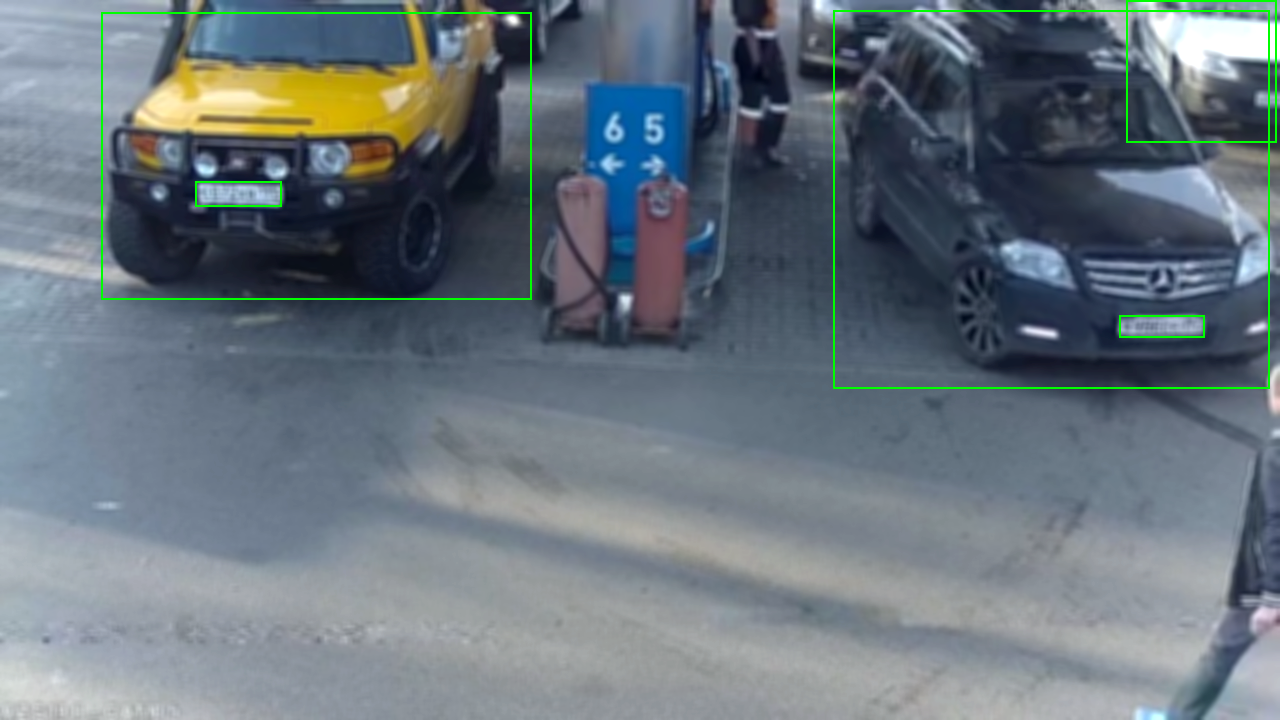

In [63]:
img, _, _ = val_dataset[random.randrange(len(val_dataset))]
H, W = img.shape[-2:]
m = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
s = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
vis = ((img * s + m).clamp(0, 1) * 255).to(torch.uint8).cpu()
model.eval()
with torch.no_grad():
    loc, conf = model(img.unsqueeze(0).to(DEVICE))
    boxes, _, _ = detect_objects(loc, conf, priors, cfg["num_classes"], 0.5, 0.7)
b = boxes[0]
b = (b.reshape(-1, 4) * torch.tensor([W, H, W, H], device=b.device)).cpu() if b.numel() else torch.zeros(0, 4)
display(to_pil_image(draw_bounding_boxes(vis, b, colors="lime", width=2)))